<a href="https://colab.research.google.com/github/k1garcia/Subject_Specific_Biventricular_Model_PAH/blob/main/Hozapfel_Ogden_Model_Parameter_Fitting_Controller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Fitting Controller**



In [ ]:
#@title Run to Mount Drive
#@markdown When authenticating, copy the link by highlighting and using CRTL-C, not the copy button. For some reason, Google Colab has a bug where it will only run once properly if you use the copy button.
%%capture
#### Mounting the Google Drive to load data and importing the necessary code files ####
from google.colab import drive
from google.colab import auth
from oauth2client.client import GoogleCredentials
drive.mount('/content/gdrive',force_remount=True)
import os
import sys

%pip install --upgrade gspread
import gspread

auth.authenticate_user()
#from oauth2client.client import GoogleCredentials
from google.auth import default
creds, _ = default()

#gc = gspread.authorize(GoogleCredentials.get_application_default())
gc = gspread.authorize(creds)

analysis_folder = '/content/gdrive/Shared drives/DVJ Lab Drive/2. Data/4. Planar Biaxial Testing/' ## if using this code as a basis for other controllers, change the last two folder names to match your experiment
code_folder = '9. Analysis Code'  ## if reusing this code, change this to match the name of the folder containing all of your analysis code files
sys.path.append(analysis_folder + code_folder)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as opt

from Functions import *
import DVJ_Utilities as utils

os.chdir(analysis_folder) # moving to the root analysis folder


In [ ]:
#@title HO 2nd PK Model fit

# --- Clean HO → 2nd-PK (aligned; tension-only; incompressible surface) ---
def HO_Model_full_2PK(L, params, fiber_dir='dir1'):
    a, b, af, bf, as_, bs, afs, bfs, asn, bsn, anf, bnf, k = params
    lam1, lam2 = L
    lam3 = 1.0/(lam1*lam2)  # J=1 in planar biax

    I1  = lam1**2 + lam2**2 + lam3**2
    I4f = lam1**2            # fiber || axis-1
    I4s = lam2**2            # sheet || axis-2

    # tension-only gates
    phi_f = np.maximum(I4f - 1.0, 0.0)
    phi_s = np.maximum(I4s - 1.0, 0.0)

    dPsi_dI1  = (a/2.0)*np.exp(b*(I1-3.0))
    dPsi_dI4f = af*np.exp(bf*(phi_f**2))*phi_f
    dPsi_dI4s = as_*np.exp(bs*(phi_s**2))*phi_s

    S11 = 2.0*dPsi_dI1 + 2.0*dPsi_dI4f
    S22 = 2.0*dPsi_dI1 + 2.0*dPsi_dI4s
    return S11, S22

# --- Weighted error on 2nd-PK ---
def err_HO_full_weighted(S, L, params, fiber_dir='dir1', alpha=4.0):
    S11d, S22d = S
    lam1, lam2 = L
    S11m, S22m = HO_Model_full_2PK(L, params, fiber_dir)

    # weights grow with stretch; ensure all arrays have same length BEFORE calling this
    lam_max = np.maximum(lam1, lam2)
    w = np.maximum(1.0 + alpha*(lam_max - 1.0), 1.0)

    n = min(len(S11d), len(S11m), len(S22d), len(S22m), len(w))
    return np.sum(w[:n]*(S11d[:n]-S11m[:n])**2) + np.sum(w[:n]*(S22d[:n]-S22m[:n])**2)


# ---- define BEFORE you call get_safe_params_0 ----
def get_safe_params_0(tissue_type='soft', bounds_style='safe'):
    # initial guesses
    if tissue_type == 'soft':
        a0,b0 = 2.0,10.0;  af0,bf0 = 1.0,10.0;  as0,bs0 = 1.0,20.0
    elif tissue_type == 'medium':
        a0,b0 = 4.0,20.0;  af0,bf0 = 2.0,12.0;  as0,bs0 = 2.0,40.0
    elif tissue_type == 'stiff':
        a0,b0 = 6.0,30.0;  af0,bf0 = 3.0,15.0;  as0,bs0 = 3.0,60.0
    else:
        raise ValueError("tissue_type must be 'soft', 'medium', or 'stiff'")

    # terms we keep zero in planar fits
    afs0=bfs0=asn0=bsn0=anf0=bnf0=0.0

    # bulk term is irrelevant in 2D fit; fix it to a constant
    k0 = 0.5  # pick a value and keep bounds equal to it

    params_0 = (a0,b0,af0,bf0,as0,bs0, afs0,bfs0, asn0,bs0, anf0,bnf0, k0)

    # bounds
    if     bounds_style == 'safe':  bf_lo,bf_hi = 5.0,30.0;  bs_lo,bs_hi = 5.0,80.0
    elif   bounds_style == 'loose': bf_lo,bf_hi = 2.0,40.0;  bs_lo,bs_hi = 2.0,120.0
    elif   bounds_style == 'tight': bf_lo,bf_hi = 8.0,25.0;  bs_lo,bs_hi = 8.0,60.0
    else:  raise ValueError("bounds_style must be 'safe', 'loose', or 'tight'")

    eps = 1e-3  # tiny positive floor so af doesn't get stuck at 0 boundary
    bounds = [
        (0,None), (0,None),            # a, b
        (eps,None), (bf_lo,bf_hi),     # af, bf
        (0,None),  (bs_lo,bs_hi),      # as, bs
        (0,0), (0,0),                  # afs, bfs
        (0,0), (0,0),                  # asn, bsn
        (0,0), (0,0),                  # anf, bnf
        (k0,k0)                        # k fixed to exactly k0
    ]
    return params_0, bounds

In [ ]:
#@title Animal Selection
matplotlib.rcParams['figure.figsize'] = [8,6]

os.chdir(analysis_folder) # moving to the root analysis folder
#@markdown Choose an experimental group:
Group = '2. Male SUHX' #@param ['0. Male Control','2. Male SUHX','3. Female Control','4. Female SUHX','5. OVX Control','6. OVX SUHX']
#@markdown Enter the animal tag number
Number = '325' #@param {type:'string'}
#@markdown Enter sample tag (A,B) if applicable
Tag = 'RV' #@param {type:'string'}
#@markdown Enter the trial number
Trial = '6' #@param {type:'string'}
#@markdown Select the thickness measure:
Thickness = 'Calipers' #@param ['Calipers','Dial']

isFemale = 'Female' in Group
isOVX = 'OVX' in Group

os.chdir(Group+'/')
rats = os.listdir()
check = []
for rat in rats:
  if 'RAT'+Number+'_' in rat:
    check.append(rat)
  elif isFemale:
    if 'RAT'+Number+'F_' in rat:
      check.append(rat)
  elif isOVX:
    if 'RAT'+Number+'OVX_' in rat:
      check.append(rat)
if not (Tag == ' ' or Tag == ''):
  for folder in check:
    if ('_'+Tag) not in folder:
      check.remove(folder)


if len(check) > 1:
  check = input("Multiple folder fulfill this discription. Please type the directory of the folder you are trying to access.")
elif len(check) == 0:
  print('Folder not found. Please check for accurate naming convention. If the folder is properly name, factory restart this notebook and try again')
else:
  folder = check[0]

print('Folder: ', folder)
geo_data = gc.open_by_url('https://docs.google.com/spreadsheets/d/1C_a7g9UNtvfbeM8X42o1tDsfVT4JH69U_UglfouffSs/edit#gid=0')
intact_worksheets = {'0. Male Control':0,'2. Male SUHX':1,'3. Female Control':2,'4. Female SUHX':3,'5. OVX Control':4,'6. OVX SUHX':5}
intact_data = geo_data.get_worksheet(intact_worksheets[Group])

## getting intact geometry and best trial
rats = intact_data.col_values(1)[1:]
row = [ i for i in range(len(rats)) if rats[i] == Number ]
if len(row)>1:
  if Tag in intact_data.row_values(row[0]+2):
    geo = intact_data.row_values(row[0]+2)
  else:
    geo = intact_data.row_values(row[1]+2)
else:
  geo = intact_data.row_values(row[0] +2)
Intact_Geometry = list(map(float,geo[3:7]))
Intact_folder = analysis_folder + Group + '/' + folder + '/0. Intact'+ '/Trial ' + Trial

print('Group:                       ',Group[3:])
print('Rat:                         ',check[0])
print('Trial:                       ',Trial)
print('Apex-Outflow length [mm]:    ',Intact_Geometry[0])
print('Circumferential length [mm]: ',Intact_Geometry[1])
if Thickness=='Calipers':
  print('Thickness [in]:              ',Intact_Geometry[2])
elif Thickness=='Dial':
  print('Thickness [in]:              ',Intact_Geometry[3])


## gathering data for Intact Best Trial
os.chdir(Intact_folder)
files = os.listdir()
datafile = None
reffile = None
for f in files:
  if ('New5RefData2Model.txt' in f) or ('New5RefData2Model.TXT' in f):
      datafile = f
  if ('Ref5Conf' in f):
      reffile = f
if datafile is None:
  print('Intact data file not found. Please check that is was calculated, or try Factory Restarting the notebook.')
elif reffile is None:
  print('Intact reference configuration not found.')
else:
  try:
    data = np.loadtxt(datafile) # loading in the stress, strain, and strain energy data
  except:
    data = np.loadtxt(datafile,delimiter=',') # loading in the stress, strain, and strain energy data
  try:
    refconf = np.loadtxt(reffile) # loading in the reference configuration
  except:
    refconf = np.loadtxt(reffile,delimiter=',') # loading in the reference configuration
  intact_E11 = data[:,0]
  intact_E22 = data[:,1]
  intact_S11 = data[:,2]/1000
  intact_S22 = data[:,3]/1000
  intact_W = data[:,4]

  intact_refConf = refconf.reshape(2,4,5)

Folder:  RAT325_W8_RV
Group:                        Male SUHX
Rat:                          RAT325_W8_RV
Trial:                        6
Apex-Outflow length [mm]:     8.57
Circumferential length [mm]:  8.84
Thickness [in]:               0.088


Optimized parameters (reduced): [ 1.58847522 37.19724551 19.08328207 22.00545427 16.88840396 24.70370165
  0.          0.          0.          0.          0.          0.
  0.5       ]
Optimization status: Succeeded
Final error: 3464.163728206636


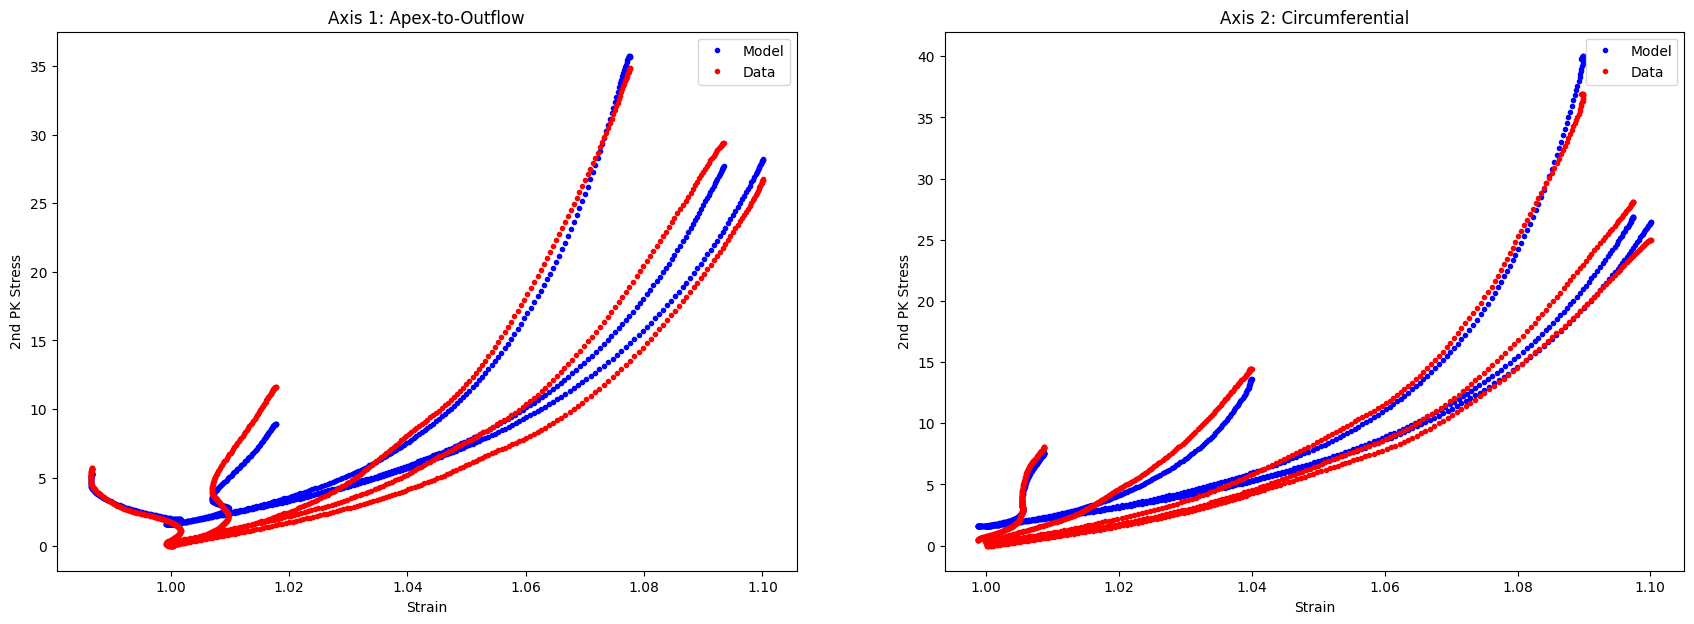

Coefficient of Determination (R²): 0.9812509661349595


/tmp/ipython-input-2373221948.py:94: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  param_sheet.update('B3:O3',[[a, b, af, bf, as_, bs, afs, bfs, asn, bsn, anf, bnf, k, R2]])


{'spreadsheetId': '13-ayuCk7mnfxjwrUEqxT5CCEU8lM-95ONR_Ioj5Y1Iw',
 'updatedRange': "'Code Output'!P3",
 'updatedRows': 1,
 'updatedColumns': 1,
 'updatedCells': 1}

In [ ]:
#@title Fitting the HO model to your planar biaxial data
# --- Compute stretches from E11 and E22 ---
lam1 = np.sqrt(2.0 * intact_E11 + 1.0).astype(float)
lam2 = np.sqrt(2.0 * intact_E22 + 1.0).astype(float)
intact_S11 = np.asarray(intact_S11, dtype=float)
intact_S22 = np.asarray(intact_S22, dtype=float)

# --- Force EVERYTHING to a common length ---
N = min(len(lam1), len(lam2), len(intact_S11), len(intact_S22))
lam1 = lam1[:N]
lam2 = lam2[:N]
intact_S11 = intact_S11[:N]
intact_S22 = intact_S22[:N]

# --- Get safe initial guess and bounds ---
# Choose tissue type: 'soft', 'medium', 'stiff'
#@markdown Choose tissue type for initial guess:
tissue_type = 'soft' #@param ['soft', 'medium', 'stiff']
#@markdown Choose bounds style:
bounds_style = 'safe' #@param ['safe', 'loose', 'tight']

# --- Get safe initial guess and bounds ---
params_0_reduced, bounds_reduced = get_safe_params_0(tissue_type=tissue_type, bounds_style=bounds_style)


# --- Define error function ---#
# err_fn_reduced = lambda params: err_HO_full((intact_S11, intact_S22), (lam1, lam2), params, fiber_dir='dir1')
err_fn_reduced = lambda params: err_HO_full_weighted(
    (intact_S11, intact_S22), (lam1, lam2), params, fiber_dir='dir1', alpha=4.0
)

# --- Run optimization ---
res = opt.minimize(err_fn_reduced, params_0_reduced, method='L-BFGS-B',
                   bounds=bounds_reduced, options={'maxiter': 10000})

params_opt_reduced = res.x
err_min = res.fun
success = res.success

print('Optimized parameters (reduced):', params_opt_reduced)
print('Optimization status:', ('Failed', 'Succeeded')[success])
print('Final error:', err_min)

# --- Compute model stress for plotting ---
S11_model, S22_model = HO_Model_full_2PK((lam1, lam2), params_opt_reduced, fiber_dir='dir1')

# --- Plot ---
fig, ax = plt.subplots(1, 2, figsize=(21, 7))

# Axis 1
ax[0].plot(lam1, S11_model, '.b', lam1, intact_S11, '.r')
ax[0].set_xlabel('Strain')
ax[0].set_ylabel('2nd PK Stress')
ax[0].legend(['Model', 'Data'])
ax[0].set_title('Axis 1: Apex-to-Outflow')

# Axis 2
ax[1].plot(lam2, S22_model, '.b', lam2, intact_S22, '.r')
ax[1].set_xlabel('Strain')
ax[1].set_ylabel('2nd PK Stress')
ax[1].legend(['Model', 'Data'])
ax[1].set_title('Axis 2: Circumferential')

plt.show()

# --- Optional R² computation ---
SS_res = np.sum((intact_S11 - S11_model)**2) + np.sum((intact_S22 - S22_model)**2)
S_bar = np.mean(np.hstack((intact_S11, intact_S22)))
SS_tot = np.sum((intact_S11 - S_bar)**2) + np.sum((intact_S22 - S_bar)**2)

R2 = 1 - (SS_res / SS_tot)
print('Coefficient of Determination (R²):', R2)

# Assign params for clarity:
a = params_opt_reduced[0]
b = params_opt_reduced[1]
af = params_opt_reduced[2]
bf = params_opt_reduced[3]
as_ = params_opt_reduced[4]
bs = params_opt_reduced[5]
afs = params_opt_reduced[6]
bfs = params_opt_reduced[7]
asn = params_opt_reduced[8]
bsn = params_opt_reduced[9]
anf = params_opt_reduced[10]
bnf = params_opt_reduced[11]
k = params_opt_reduced[12]

# Update Google Sheet:
param_sheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/13-ayuCk7mnfxjwrUEqxT5CCEU8lM-95ONR_Ioj5Y1Iw/edit?gid=0#gid=0').worksheet('Code Output')
param_sheet.update_acell('A1',check[0] + '_Trial' + Trial)

# Print all 13 params + R²:
param_sheet.update('B3:O3',[[a, b, af, bf, as_, bs, afs, bfs, asn, bsn, anf, bnf, k, R2]])

# Also print error:
param_sheet.update_acell('P3',err_min)


In [ ]:
# Export optimized parameters to XML format for FEBio Plugin

xml_template = f"""
<material type="Holzapfel_Ogden" name="Myocardium">
  <a>{a:.6f}</a>
  <b>{b:.6f}</b>
  <af>{af:.6f}</af>
  <bf>{bf:.6f}</bf>
  <as>{as_:.6f}</as>
  <bs>{bs:.6f}</bs>
  <afs>{afs:.6f}</afs>
  <bfs>{bfs:.6f}</bfs>
  <asn>{asn:.6f}</asn>
  <bsn>{bsn:.6f}</bsn>
  <anf>{anf:.6f}</anf>
  <bnf>{bnf:.6f}</bnf>
  <k>{k:.6f}</k>
</material>
"""

# Print the XML snippet:
print(xml_template)



<material type="Holzapfel_Ogden" name="Myocardium">
  <a>20.163943</a>
  <b>28.313577</b>
  <af>3.117191</af>
  <bf>50.000000</bf>
  <as>3.217115</as>
  <bs>112.167073</bs>
  <afs>0.000000</afs>
  <bfs>0.000000</bfs>
  <asn>0.000000</asn>
  <bsn>0.000000</bsn>
  <anf>0.000000</anf>
  <bnf>0.000000</bnf>
  <k>0.500000</k>
</material>



In [ ]:
import numpy as np

def fraction_fiber_loaded(lam1, lam2, theta_deg=0.0):
    th = np.deg2rad(theta_deg)
    a0 = np.array([np.cos(th), np.sin(th), 0.0])  # in-plane fiber
    lam3 = 1.0 / (lam1 * lam2)                    # incompressible surface
    # Right Cauchy-Green in specimen axes (diag for pure stretches)
    C11, C22, C33 = lam1**2, lam2**2, lam3**2
    # I4f = a0^T C a0  (since C is diagonal here)
    I4f = a0[0]**2 * C11 + a0[1]**2 * C22 + a0[2]**2 * C33
    return float(np.mean(I4f > 1.0)), I4f

frac_loaded, I4f = fraction_fiber_loaded(lam1, lam2, theta_deg=0.0)  # set your assumed fiber angle
print(f"Fraction of points with I4f>1: {frac_loaded:.2f}")

Fraction of points with I4f>1: 0.98
